# What is about ? 

MoA kaggle contest.

For each target find best predicting it gene (and several best predicting - top1 , top2 ...). 
Best here - means in the sense of rocauc. 

| Target | Best Preditcting Gene | RocAuc | Number of 1 in target |
| ------ | ------ | ------ | ------ |
| atp-sensitive_potassium_channel_antagonist | 		g-161	| 0.999895	| 1 |
| proteasome_inhibitor |	 	g-349	| 0.997989| 726 |
| bacterial_membrane_integrity_inhibitor | 		g-108 | 	0.993459| 7 |
| erbb2_inhibitor | 		g-286 | 	0.992231 | 1 |



Several genes are best predictors for not just one target, but for several targers.

Gene | number of targets best predicting: 

g-392    8

g-178    5

g-75     5

g-351    4

g-628    4


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lish-moa/sample_submission.csv
/kaggle/input/lish-moa/train_targets_scored.csv
/kaggle/input/lish-moa/train_targets_nonscored.csv
/kaggle/input/lish-moa/train_features.csv
/kaggle/input/lish-moa/test_features.csv


In [2]:


import time 
import matplotlib.pyplot as plt
import seaborn as sns



# Load data

In [3]:
df = pd.read_csv('/kaggle/input/lish-moa/train_features.csv',index_col = 0)  
df

,cp_type,cp_time,cp_dose,g-0,g-1,g-2,g-3,g-4,g-5,g-6,...,c-90,c-91,c-92,c-93,c-94,c-95,c-96,c-97,c-98,c-99
sig_id,,,,,,,,,,,,,,,,,,,,,
id_000644bb2,trt_cp,24,D1,1.0620,0.5577,-0.2479,-0.6208,-0.1944,-1.0120,-1.0220,...,0.2862,0.2584,0.8076,0.5523,-0.1912,0.6584,-0.3981,0.2139,0.3801,0.4176
id_000779bfc,trt_cp,72,D1,0.0743,0.4087,0.2991,0.0604,1.0190,0.5207,0.2341,...,-0.4265,0.7543,0.4708,0.0230,0.2957,0.4899,0.1522,0.1241,0.6077,0.7371
id_000a6266a,trt_cp,48,D1,0.6280,0.5817,1.5540,-0.0764,-0.0323,1.2390,0.1715,...,-0.7250,-0.6297,0.6103,0.0223,-1.3240,-0.3174,-0.6417,-0.2187,-1.4080,0.6931
id_0015fd391,trt_cp,48,D1,-0.5138,-0.2491,-0.2656,0.5288,4.0620,-0.8095,-1.9590,...,-2.0990,-0.6441,-5.6300,-1.3780,-0.8632,-1.2880,-1.6210,-0.8784,-0.3876,-0.8154
id_001626bd3,trt_cp,72,D2,-0.3254,-0.4009,0.9700,0.6919,1.4180,-0.8244,-0.2800,...,0.0042,0.0048,0.6670,1.0690,0.5523,-0.3031,0.1094,0.2885,-0.3786,0.7125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
id_fffb1ceed,trt_cp,24,D2,0.1394,-0.0636,-0.1112,-0.5080,-0.4713,0.7201,0.5773,...,0.1969,0.0262,-0.8121,0.3434,0.5372,-0.3246,0.0631,0.9171,0.5258,0.4680
id_fffb70c0c,trt_cp,24,D2,-1.3260,0.3478,-0.3743,0.9905,-0.7178,0.6621,-0.2252,...,0.4286,0.4426,0.0423,-0.3195,-0.8086,-0.9798,-0.2084,-0.1224,-0.2715,0.3689
id_fffc1c3f4,ctl_vehicle,48,D2,0.3942,0.3756,0.3109,-0.7389,0.5505,-0.0159,-0.2541,...,0.5409,0.3755,0.7343,0.2807,0.4116,0.6422,0.2256,0.7592,0.6656,0.3808


In [4]:
df_test = pd.read_csv('/kaggle/input/lish-moa/test_features.csv',index_col = 0)  
df_test

,cp_type,cp_time,cp_dose,g-0,g-1,g-2,g-3,g-4,g-5,g-6,...,c-90,c-91,c-92,c-93,c-94,c-95,c-96,c-97,c-98,c-99
sig_id,,,,,,,,,,,,,,,,,,,,,
id_0004d9e33,trt_cp,24,D1,-0.5458,0.1306,-0.5135,0.4408,1.5500,-0.1644,-0.2140,...,0.0981,0.7978,-0.1430,-0.2067,-0.2303,-0.1193,0.0210,-0.0502,0.1510,-0.7750
id_001897cda,trt_cp,72,D1,-0.1829,0.2320,1.2080,-0.4522,-0.3652,-0.3319,-1.8820,...,-0.1190,-0.1852,-1.0310,-1.3670,-0.3690,-0.5382,0.0359,-0.4764,-1.3810,-0.7300
id_002429b5b,ctl_vehicle,24,D1,0.1852,-0.1404,-0.3911,0.1310,-1.4380,0.2455,-0.3390,...,-0.2261,0.3370,-1.3840,0.8604,-1.9530,-1.0140,0.8662,1.0160,0.4924,-0.1942
id_00276f245,trt_cp,24,D2,0.4828,0.1955,0.3825,0.4244,-0.5855,-1.2020,0.5998,...,0.1260,0.1570,-0.1784,-1.1200,-0.4325,-0.9005,0.8131,-0.1305,0.5645,-0.5809
id_0027f1083,trt_cp,48,D1,-0.3979,-1.2680,1.9130,0.2057,-0.5864,-0.0166,0.5128,...,0.4965,0.7578,-0.1580,1.0510,0.5742,1.0900,-0.2962,-0.5313,0.9931,1.8380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
id_ff7004b87,trt_cp,24,D1,0.4571,-0.5743,3.3930,-0.6202,0.8557,1.6240,0.0640,...,-1.1790,-0.6422,-0.4367,0.0159,-0.6539,-0.4791,-1.2680,-1.1280,-0.4167,-0.6600
id_ff925dd0d,trt_cp,24,D1,-0.5885,-0.2548,2.5850,0.3456,0.4401,0.3107,-0.7437,...,0.0210,0.5780,-0.5888,0.8057,0.9312,1.2730,0.2614,-0.2790,-0.0131,-0.0934
id_ffb710450,trt_cp,72,D1,-0.3985,-0.1554,0.2677,-0.6813,0.0152,0.4791,-0.0166,...,0.4418,0.9153,-0.1862,0.4049,0.9568,0.4666,0.0461,0.5888,-0.4205,-0.1504


In [5]:
y = pd.read_csv('/kaggle/input/lish-moa/train_targets_scored.csv',index_col = 0 )
y

,5-alpha_reductase_inhibitor,11-beta-hsd1_inhibitor,acat_inhibitor,acetylcholine_receptor_agonist,acetylcholine_receptor_antagonist,acetylcholinesterase_inhibitor,adenosine_receptor_agonist,adenosine_receptor_antagonist,adenylyl_cyclase_activator,adrenergic_receptor_agonist,...,tropomyosin_receptor_kinase_inhibitor,trpv_agonist,trpv_antagonist,tubulin_inhibitor,tyrosine_kinase_inhibitor,ubiquitin_specific_protease_inhibitor,vegfr_inhibitor,vitamin_b,vitamin_d_receptor_agonist,wnt_inhibitor
sig_id,,,,,,,,,,,,,,,,,,,,,
id_000644bb2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_000779bfc,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_000a6266a,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_0015fd391,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_001626bd3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
id_fffb1ceed,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_fffb70c0c,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_fffc1c3f4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
y_additional = pd.read_csv('/kaggle/input/lish-moa/train_targets_nonscored.csv',index_col = 0 )
y_additional

,abc_transporter_expression_enhancer,abl_inhibitor,ace_inhibitor,acetylcholine_release_enhancer,adenosine_deaminase_inhibitor,adenosine_kinase_inhibitor,adenylyl_cyclase_inhibitor,age_inhibitor,alcohol_dehydrogenase_inhibitor,aldehyde_dehydrogenase_activator,...,ve-cadherin_antagonist,vesicular_monoamine_transporter_inhibitor,vitamin_k_antagonist,voltage-gated_calcium_channel_ligand,voltage-gated_potassium_channel_activator,voltage-gated_sodium_channel_blocker,wdr5_mll_interaction_inhibitor,wnt_agonist,xanthine_oxidase_inhibitor,xiap_inhibitor
sig_id,,,,,,,,,,,,,,,,,,,,,
id_000644bb2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_000779bfc,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_000a6266a,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_0015fd391,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_001626bd3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
id_fffb1ceed,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_fffb70c0c,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_fffc1c3f4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Look at targets - number of 1 in each target

2 targets have only one 1 :
atp-sensitive_potassium_channel_antagonist  , 
erbb2_inhibitor

16 targets have 6 one, 4 targets have 7 ones, 1 target has 17 ones, 13 targets have 18 one 





In [7]:
z = y.sum(axis = 0)
print( (z==6).sum() , (z==7).sum(),   (z==12).sum(),  (z==13).sum(), (z==17).sum(),  (z==18).sum(),  )
z.sort_values()[:40] #.value_counts()

16 4 11 2 1 13


atp-sensitive_potassium_channel_antagonist          1
erbb2_inhibitor                                     1
diuretic                                            6
autotaxin_inhibitor                                 6
protein_phosphatase_inhibitor                       6
antiarrhythmic                                      6
retinoid_receptor_antagonist                        6
nicotinic_receptor_agonist                          6
atm_kinase_inhibitor                                6
calcineurin_inhibitor                               6
lxr_agonist                                         6
elastase_inhibitor                                  6
steroid                                             6
leukotriene_inhibitor                               6
coagulation_factor_inhibitor                        6
ubiquitin_specific_protease_inhibitor               6
tropomyosin_receptor_kinase_inhibitor               6
laxative                                            6
norepinephrine_reuptake_inhi

In [8]:
z.sort_values()[-40:] #.value_counts()

protein_synthesis_inhibitor                103
cytochrome_p450_inhibitor                  104
hdac_inhibitor                             106
gaba_receptor_agonist                      106
bacterial_dna_inhibitor                    115
ppar_receptor_agonist                      115
progesterone_receptor_agonist              119
dopamine_receptor_agonist                  121
topoisomerase_inhibitor                    127
mtor_inhibitor                             130
pi3k_inhibitor                             151
estrogen_receptor_agonist                  158
gaba_receptor_antagonist                   165
vegfr_inhibitor                            170
acetylcholine_receptor_agonist             190
bacterial_cell_wall_synthesis_inhibitor    192
raf_inhibitor                              223
serotonin_receptor_agonist                 236
histamine_receptor_antagonist              241
phosphodiesterase_inhibitor                264
glucocorticoid_receptor_agonist            266
sodium_channe

# Main loop to find for each target a best predicting gene

Takes 1256 seconds 

1 5-alpha_reductase_inhibitor 0.00027251243591308594 secs passed
1 Best Auc: 0.8021413969630379 For Gen: g-278 LenSetBestGenes: 1
2 11-beta-hsd1_inhibitor 6.191920757293701 secs passed
2 Best Auc: 0.7714765320035113 For Gen: g-140 LenSetBestGenes: 2
3 acat_inhibitor 11.59433126449585 secs passed
3 Best Auc: 0.6669880552052683 For Gen: g-414 LenSetBestGenes: 3
4 acetylcholine_receptor_agonist 16.85846996307373 secs passed
4 Best Auc: 0.6035267435435864 For Gen: g-406 LenSetBestGenes: 4
5 acetylcholine_receptor_antagonist 22.325576305389404 secs passed
5 Best Auc: 0.6242370623277178 For Gen: g-392 LenSetBestGenes: 5
6 acetylcholinesterase_inhibitor 27.853588581085205 secs passed
6 Best Auc: 0.6475428612313362 For Gen: g-392 LenSetBestGenes: 5
7 adenosine_receptor_agonist 33.32819890975952 secs passed
7 Best Auc: 0.6576568150642225 For Gen: g-489 LenSetBestGenes: 6
8 adenosine_receptor_antagonist 38.63990640640259 secs passed
8 Best Auc: 0.620434418655311 For Gen: g-322 LenSetBestGenes: 7

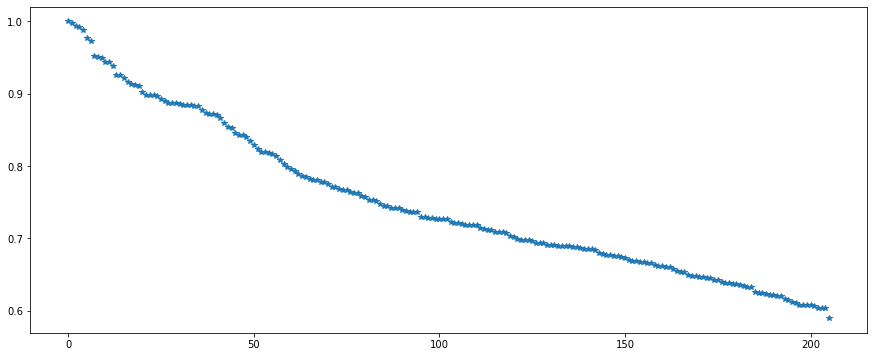

atp-sensitive_potassium_channel_antagonist    0.999895
proteasome_inhibitor                          0.997989
bacterial_membrane_integrity_inhibitor        0.993459
erbb2_inhibitor                               0.992231
tgf-beta_receptor_inhibitor                   0.988061
                                                ...   
gaba_receptor_agonist                         0.605760
serotonin_receptor_agonist                    0.604103
glutamate_receptor_antagonist                 0.603844
acetylcholine_receptor_agonist                0.603527
calcium_channel_blocker                       0.589710
Length: 206, dtype: float64

In [9]:
from sklearn.metrics import roc_auc_score
df_features_stat = pd.DataFrame()

df_stat = pd.DataFrame()
i=0
t0 = time.time()
set_best_predictor = set()
for t in y.columns:
    i+=1
    print(i, t, time.time() -t0,'secs passed')
    for f in df.columns: #['g-100']:
        if 'g-' not in f:
            continue
        try:
            r = roc_auc_score(y[t], df[f] )
        except:
            continue
        #print(r, )
        df_stat.loc[t , f ] =  np.abs(r-0.5)+0.5 
        
    set_best_predictor.add(df_stat.columns[df_stat.loc[t,:].argmax()])
    print(i, 'Best Auc:',df_stat.loc[t,:].max(), 'For Gen:',  df_stat.columns[df_stat.loc[t,:].argmax()], 'LenSetBestGenes:', len( set_best_predictor ) )
    
    #if i > 2: break   
        
v = df_stat.max(axis = 1)
v.sort_values(inplace = True, ascending = False) # ('rocauc Abs', inplace = True, ascending = False)

plt.figure(figsize = (15,6))
plt.plot(v.values,'*')        
plt.show()

v

# Output for each target 5 best predicting genes 

In [10]:
df_association = pd.DataFrame()

for t in df_stat.index:
    df_association.loc[t,'#1'] = y[t].sum()
    v = df_stat.loc[t,:]
    v.sort_values(inplace = True, ascending = False)
    for i in range(8):
        df_association.loc[t,'Top'+str(i+1)+'Gen'] = v.index[i]
    #for i in range(1):
    df_association.loc[t,'WorstGen'] = v.index[-1]
    for i in range(8):
        df_association.loc[t,'Top'+str(i+1)+'Auc'] = v.iloc[i]
    #for i in range(1):
    df_association.loc[t,'WorstAuc'] = v.iloc[-1]

df_association.sort_values('Top1Auc',inplace = True, ascending = False )#]

df_association    

,#1,Top1Gen,Top2Gen,Top3Gen,Top4Gen,Top5Gen,Top6Gen,Top7Gen,Top8Gen,WorstGen,Top1Auc,Top2Auc,Top3Auc,Top4Auc,Top5Auc,Top6Auc,Top7Auc,Top8Auc,WorstAuc
atp-sensitive_potassium_channel_antagonist,1.0,g-161,g-605,g-259,g-486,g-421,g-521,g-194,g-732,g-553,0.999895,0.999874,0.998068,0.997018,0.996976,0.996808,0.996557,0.994121,0.500063
proteasome_inhibitor,726.0,g-349,g-228,g-368,g-464,g-123,g-460,g-406,g-168,g-442,0.997989,0.994443,0.994015,0.993310,0.993262,0.992998,0.992764,0.992703,0.500283
bacterial_membrane_integrity_inhibitor,7.0,g-108,g-372,g-634,g-139,g-235,g-437,g-215,g-0,g-143,0.993459,0.991269,0.990300,0.987393,0.983318,0.981734,0.975955,0.975226,0.500195
erbb2_inhibitor,1.0,g-286,g-610,g-765,g-391,g-430,g-309,g-49,g-670,g-631,0.992231,0.991958,0.991811,0.986058,0.983496,0.981628,0.977197,0.975287,0.500777
tgf-beta_receptor_inhibitor,30.0,g-443,g-203,g-402,g-180,g-447,g-414,g-363,g-75,g-261,0.988061,0.968213,0.955224,0.930933,0.929689,0.912683,0.910490,0.906400,0.500260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gaba_receptor_agonist,106.0,g-58,g-177,g-466,g-350,g-378,g-297,g-351,g-506,g-234,0.605760,0.600610,0.598853,0.598062,0.597519,0.597512,0.597101,0.596457,0.500008
serotonin_receptor_agonist,236.0,g-321,g-72,g-641,g-91,g-152,g-591,g-486,g-489,g-137,0.604103,0.599979,0.598069,0.594521,0.586951,0.583273,0.582045,0.581233,0.500044
glutamate_receptor_antagonist,367.0,g-351,g-158,g-439,g-297,g-443,g-628,g-322,g-761,g-608,0.603844,0.591843,0.591288,0.587732,0.587567,0.585860,0.584596,0.583787,0.500071
acetylcholine_receptor_agonist,190.0,g-406,g-91,g-365,g-158,g-223,g-185,g-37,g-418,g-240,0.603527,0.603420,0.599851,0.599036,0.597836,0.597537,0.596214,0.593873,0.500044


In [11]:
df_association.head(30)

,#1,Top1Gen,Top2Gen,Top3Gen,Top4Gen,Top5Gen,Top6Gen,Top7Gen,Top8Gen,WorstGen,Top1Auc,Top2Auc,Top3Auc,Top4Auc,Top5Auc,Top6Auc,Top7Auc,Top8Auc,WorstAuc
atp-sensitive_potassium_channel_antagonist,1.0,g-161,g-605,g-259,g-486,g-421,g-521,g-194,g-732,g-553,0.999895,0.999874,0.998068,0.997018,0.996976,0.996808,0.996557,0.994121,0.500063
proteasome_inhibitor,726.0,g-349,g-228,g-368,g-464,g-123,g-460,g-406,g-168,g-442,0.997989,0.994443,0.994015,0.993310,0.993262,0.992998,0.992764,0.992703,0.500283
bacterial_membrane_integrity_inhibitor,7.0,g-108,g-372,g-634,g-139,g-235,g-437,g-215,g-0,g-143,0.993459,0.991269,0.990300,0.987393,0.983318,0.981734,0.975955,0.975226,0.500195
erbb2_inhibitor,1.0,g-286,g-610,g-765,g-391,g-430,g-309,g-49,g-670,g-631,0.992231,0.991958,0.991811,0.986058,0.983496,0.981628,0.977197,0.975287,0.500777
tgf-beta_receptor_inhibitor,30.0,g-443,g-203,g-402,g-180,g-447,g-414,g-363,g-75,g-261,0.988061,0.968213,0.955224,0.930933,0.929689,0.912683,0.910490,0.906400,0.500260
atp_synthase_inhibitor,12.0,g-108,g-635,g-235,g-284,g-437,g-133,g-547,g-231,g-240,0.976593,0.972376,0.961089,0.952585,0.931989,0.929827,0.928854,0.927748,0.500483
lxr_agonist,6.0,g-178,g-487,g-357,g-156,g-712,g-157,g-494,g-429,g-69,0.973517,0.881706,0.861780,0.854853,0.850869,0.849438,0.840908,0.840064,0.500406
atr_kinase_inhibitor,19.0,g-763,g-392,g-723,g-254,g-628,g-148,g-50,g-670,g-308,0.952127,0.884636,0.880224,0.867253,0.851798,0.839617,0.831817,0.829188,0.500053
aldehyde_dehydrogenase_inhibitor,7.0,g-722,g-199,g-623,g-324,g-679,g-507,g-95,g-231,g-643,0.950063,0.934260,0.927314,0.922364,0.915775,0.911629,0.911203,0.910326,0.500627
glucocorticoid_receptor_agonist,266.0,g-175,g-202,g-231,g-100,g-122,g-181,g-504,g-447,g-625,0.948962,0.941288,0.939046,0.935582,0.925454,0.904280,0.901582,0.897454,0.500135


In [12]:
df_association[ ['#1', 'Top1Gen','Top1Auc', 'Top2Gen','Top2Auc',]].head(30) # ,inplace = True, ascending = False )#]


,#1,Top1Gen,Top1Auc,Top2Gen,Top2Auc
atp-sensitive_potassium_channel_antagonist,1.0,g-161,0.999895,g-605,0.999874
proteasome_inhibitor,726.0,g-349,0.997989,g-228,0.994443
bacterial_membrane_integrity_inhibitor,7.0,g-108,0.993459,g-372,0.991269
erbb2_inhibitor,1.0,g-286,0.992231,g-610,0.991958
tgf-beta_receptor_inhibitor,30.0,g-443,0.988061,g-203,0.968213
atp_synthase_inhibitor,12.0,g-108,0.976593,g-635,0.972376
lxr_agonist,6.0,g-178,0.973517,g-487,0.881706
atr_kinase_inhibitor,19.0,g-763,0.952127,g-392,0.884636
aldehyde_dehydrogenase_inhibitor,7.0,g-722,0.950063,g-199,0.934260
glucocorticoid_receptor_agonist,266.0,g-175,0.948962,g-202,0.941288


In [13]:
df_association.tail(30)

,#1,Top1Gen,Top2Gen,Top3Gen,Top4Gen,Top5Gen,Top6Gen,Top7Gen,Top8Gen,WorstGen,Top1Auc,Top2Auc,Top3Auc,Top4Auc,Top5Auc,Top6Auc,Top7Auc,Top8Auc,WorstAuc
potassium_channel_antagonist,98.0,g-335,g-723,g-503,g-105,g-460,g-21,g-724,g-421,g-676,0.639826,0.619055,0.615062,0.614025,0.613193,0.608874,0.608856,0.607886,0.500102
hcv_inhibitor,72.0,g-208,g-706,g-36,g-417,g-534,g-680,g-74,g-357,g-482,0.638454,0.623232,0.619312,0.615755,0.615445,0.615069,0.614051,0.613129,0.500101
anesthetic_-_local,80.0,g-192,g-392,g-126,g-206,g-569,g-756,g-322,g-757,g-315,0.637714,0.636077,0.627259,0.624627,0.624518,0.621640,0.618255,0.617018,0.500298
bacterial_dna_inhibitor,115.0,g-586,g-194,g-197,g-765,g-664,g-643,g-618,g-52,g-408,0.636531,0.630196,0.621369,0.620831,0.612264,0.608985,0.608887,0.608310,0.500072
trpv_antagonist,48.0,g-379,g-386,g-664,g-750,g-157,g-42,g-460,g-298,g-517,0.636213,0.633021,0.632621,0.630794,0.623814,0.622126,0.621777,0.621100,0.500105
monoamine_oxidase_inhibitor,85.0,g-163,g-692,g-142,g-249,g-298,g-235,g-126,g-369,g-171,0.635733,0.625123,0.623603,0.620190,0.616173,0.611783,0.611537,0.610705,0.500004
serotonin_receptor_antagonist,404.0,g-322,g-106,g-142,g-423,g-297,g-392,g-52,g-139,g-498,0.633333,0.606726,0.603636,0.603341,0.603237,0.602335,0.600085,0.599574,0.500035
membrane_integrity_inhibitor,74.0,g-294,g-740,g-265,g-464,g-285,g-771,g-62,g-628,g-119,0.632912,0.629891,0.625629,0.624261,0.622347,0.614498,0.614088,0.613209,0.500079
adrenergic_receptor_agonist,270.0,g-337,g-63,g-91,g-723,g-113,g-731,g-745,g-322,g-366,0.632186,0.627547,0.622505,0.604919,0.603779,0.601885,0.601682,0.601569,0.500001
phosphodiesterase_inhibitor,264.0,g-478,g-418,g-91,g-744,g-386,g-257,g-365,g-52,g-571,0.625665,0.614055,0.601752,0.595931,0.595158,0.595065,0.594728,0.594448,0.500037


In [14]:
#  Genes which best predict several targets 
df_association[ 'Top1Gen'].value_counts().head(20)

g-392    8
g-75     5
g-178    5
g-628    4
g-351    4
g-202    3
g-763    3
g-91     3
g-534    3
g-206    3
g-701    3
g-322    3
g-140    2
g-385    2
g-208    2
g-476    2
g-726    2
g-418    2
g-146    2
g-52     2
Name: Top1Gen, dtype: int64

In [15]:
# What targets are predicted by g-392 which is best predictor for 8 targets ( that gene is top is that respect)  
m = df_association[  'Top1Gen' ] == 'g-392'
df_association[m]

,#1,Top1Gen,Top2Gen,Top3Gen,Top4Gen,Top5Gen,Top6Gen,Top7Gen,Top8Gen,WorstGen,Top1Auc,Top2Auc,Top3Auc,Top4Auc,Top5Auc,Top6Auc,Top7Auc,Top8Auc,WorstAuc
focal_adhesion_kinase_inhibitor,18.0,g-392,g-68,g-763,g-20,g-398,g-670,g-274,g-619,g-635,0.913203,0.907724,0.907657,0.873675,0.873191,0.872036,0.871828,0.866446,0.500042
tubulin_inhibitor,316.0,g-392,g-152,g-361,g-75,g-569,g-91,g-291,g-577,g-187,0.887731,0.868008,0.866065,0.865820,0.863978,0.863728,0.863324,0.851412,0.500266
p38_mapk_inhibitor,62.0,g-392,g-158,g-763,g-75,g-269,g-562,g-186,g-47,g-274,0.819738,0.773726,0.756991,0.755733,0.742006,0.738925,0.737306,0.735546,0.500221
histamine_receptor_agonist,59.0,g-392,g-641,g-59,g-318,g-443,g-37,g-569,g-702,g-583,0.688937,0.648617,0.646477,0.640531,0.638346,0.637263,0.634028,0.632924,0.500020
acetylcholinesterase_inhibitor,73.0,g-392,g-701,g-147,g-130,g-693,g-199,g-386,g-503,g-56,0.647543,0.639365,0.639143,0.634438,0.622189,0.619985,0.618244,0.617572,0.500130
acetylcholine_receptor_antagonist,301.0,g-392,g-386,g-322,g-248,g-486,g-37,g-52,g-669,g-20,0.624237,0.609884,0.609662,0.608642,0.607980,0.606812,0.605479,0.603165,0.500018
dopamine_receptor_antagonist,424.0,g-392,g-322,g-106,g-147,g-157,g-701,g-600,g-540,g-360,0.609864,0.606384,0.592635,0.589257,0.588619,0.586187,0.586168,0.584661,0.500184
cyclooxygenase_inhibitor,435.0,g-392,g-206,g-386,g-377,g-443,g-140,g-100,g-38,g-393,0.607988,0.597649,0.596893,0.596445,0.592917,0.590644,0.589648,0.585557,0.500194


In [16]:
# What targets are predicted by g-178 which is best predictor for 5  targets ( that gene is subtop is that respect) 
m = df_association[  'Top1Gen' ] == 'g-178'
df_association[m]

,#1,Top1Gen,Top2Gen,Top3Gen,Top4Gen,Top5Gen,Top6Gen,Top7Gen,Top8Gen,WorstGen,Top1Auc,Top2Auc,Top3Auc,Top4Auc,Top5Auc,Top6Auc,Top7Auc,Top8Auc,WorstAuc
lxr_agonist,6.0,g-178,g-487,g-357,g-156,g-712,g-157,g-494,g-429,g-69,0.973517,0.881706,0.861780,0.854853,0.850869,0.849438,0.840908,0.840064,0.500406
hmgcr_inhibitor,283.0,g-178,g-157,g-156,g-125,g-48,g-75,g-300,g-767,g-142,0.944388,0.941966,0.891317,0.806955,0.783768,0.783531,0.769845,0.761144,0.500126
atm_kinase_inhibitor,6.0,g-178,g-696,g-148,g-418,g-60,g-271,g-441,g-157,g-190,0.925214,0.909684,0.898949,0.873502,0.858808,0.857621,0.856690,0.849228,0.500147
flt3_inhibitor,279.0,g-178,g-157,g-34,g-522,g-207,g-146,g-22,g-125,g-5,0.708055,0.705214,0.695333,0.684090,0.683694,0.679014,0.677566,0.675751,0.500219
pdgfr_inhibitor,297.0,g-178,g-157,g-424,g-34,g-156,g-207,g-125,g-535,g-348,0.694074,0.684932,0.669319,0.667820,0.665183,0.664674,0.664427,0.661981,0.500058


In [17]:
# What targets are predicted by g-75 which is best predictor for 5  targets ( that gene is subtop is that respect) 
m = df_association[  'Top1Gen' ] == 'g-75'
df_association[m]

,#1,Top1Gen,Top2Gen,Top3Gen,Top4Gen,Top5Gen,Top6Gen,Top7Gen,Top8Gen,WorstGen,Top1Auc,Top2Auc,Top3Auc,Top4Auc,Top5Auc,Top6Auc,Top7Auc,Top8Auc,WorstAuc
mek_inhibitor,72.0,g-75,g-769,g-283,g-512,g-207,g-203,g-379,g-441,g-469,0.892438,0.870372,0.869434,0.868380,0.868124,0.866987,0.865533,0.858544,0.500038
vitamin_d_receptor_agonist,39.0,g-75,g-627,g-414,g-516,g-357,g-325,g-239,g-124,g-518,0.870761,0.844185,0.806085,0.804676,0.782951,0.772052,0.769320,0.762723,0.500205
gamma_secretase_inhibitor,56.0,g-75,g-34,g-162,g-210,g-443,g-402,g-270,g-411,g-710,0.777483,0.773248,0.772870,0.770009,0.757940,0.732000,0.730890,0.720183,0.500320
bcr-abl_inhibitor,38.0,g-75,g-451,g-22,g-124,g-418,g-394,g-574,g-689,g-519,0.742164,0.737536,0.724756,0.722937,0.721285,0.715038,0.714830,0.711278,0.500149
src_inhibitor,71.0,g-75,g-83,g-418,g-527,g-85,g-114,g-570,g-231,g-313,0.736425,0.720938,0.719689,0.716919,0.715777,0.715771,0.713340,0.712242,0.500159


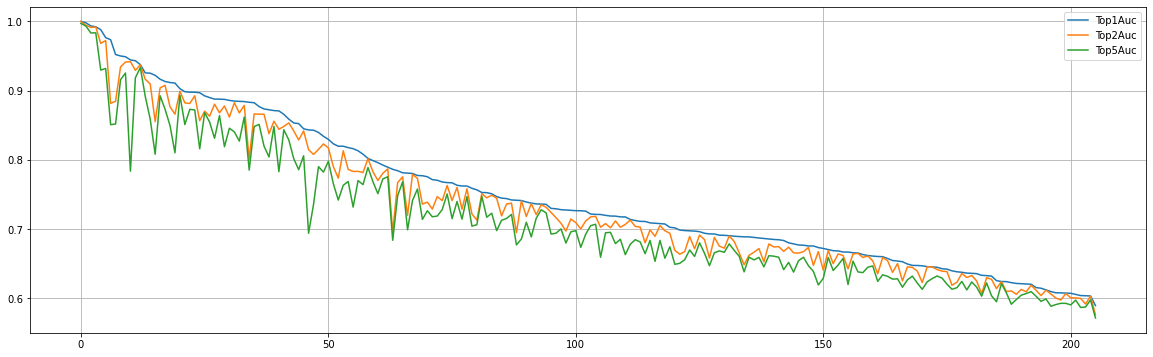

In [18]:

plt.figure(figsize = (20,6))
for f in ['Top1Auc','Top2Auc','Top5Auc']:
    plt.plot( df_association[f].values, label = f )
plt.legend()
plt.grid()
plt.show()
